# Multi-Head Stance Model — Binary (Stanced vs. Neutral), Turn-Level

Redesigned from the 5-class version. The core change:

- **Task**: binary — `stanced` (any directional label) vs. `neutral`
- **Why**: inter-model disagreement is almost entirely a neutral/stanced boundary question (κ_direction ≈ 0.92); binary heads are much easier to calibrate
- **Calibration**: post-hoc threshold per head — threshold chosen so predicted stanced rate matches each LLM's observed stanced rate on the val set
- **Swap**: clean binary decomposition — shared CLS + calibrated heads → what fraction of disagreement survives identical encoding?

Everything else (data loading, baselines, gradient attribution, meeting-level handoff) is preserved from the 5-class notebook.

In [5]:
!pip install -q transformers accelerate scikit-learn shap scipy matplotlib seaborn

In [6]:
import os, re, random
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DebertaV2Model
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import entropy, spearmanr
import shap
import warnings; warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [7]:
DATA_DIR = "/content/" if os.path.exists("/content") else "../output/stance/"

MODELS = {
    "deepseekv3":      "DeepSeek V3",
    "gemini25flash":   "Gemini 2.5 Flash",
    "gpt-4o":          "GPT-4o Mini",
    "llama33":         "Llama 3.3",
    "mistrallarge_or": "Mistral Large",
    "qwen25_72b":      "Qwen 2.5 72B",
}

# Original 5-class mapping (kept for data loading and downstream analysis)
LABEL2IDX   = {"dovish":0,"mostly dovish":1,"neutral":2,"mostly hawkish":3,"hawkish":4}
IDX2LABEL   = {v:k for k,v in LABEL2IDX.items()}
LABEL_ORDER = list(LABEL2IDX.keys())
STANCED     = {"dovish","mostly dovish","mostly hawkish","hawkish"}
SCORE_MAP   = {"dovish":-2,"mostly dovish":-1,"neutral":0,"mostly hawkish":1,"hawkish":2}

# Binary mapping for the multi-head model
BINARY_LABEL = {"neutral": 0, "stanced": 1}   # 0=neutral, 1=stanced

MODEL_NAME = "microsoft/deberta-v3-base"

def path_for(key):
    return f"{DATA_DIR}turn_predictions_{key}.csv"

## 0. Health Check

Verify every model file exists, is fully labeled, has zero `parse_error` rows.

In [8]:
raw = {}
rows = []
for key in MODELS:
    p = path_for(key)
    assert os.path.exists(p), f"MISSING: {p}"
    df = pd.read_csv(p)
    raw[key] = df
    neutral  = (df["label"] == "neutral").mean()
    stanced  = df["label"].isin(STANCED).mean()
    pe       = int((df["label"] == "parse_error").sum())
    rows.append({"model":MODELS[key], "rows":len(df),
                 "parse_error":pe, "neutral_rate":f"{neutral:.1%}",
                 "stanced_rate":f"{stanced:.1%}"})
    assert pe == 0, f"{key}: contains parse_error rows"

health = pd.DataFrame(rows).set_index("model")
print(health.to_string())
print("\nAll 6 files OK.")

                  rows  parse_error neutral_rate stanced_rate
model                                                        
DeepSeek V3       3972            0        84.7%        15.3%
Gemini 2.5 Flash  3972            0        70.6%        29.4%
GPT-4o Mini       3972            0        73.9%        26.1%
Llama 3.3         3972            0        69.8%        30.2%
Mistral Large     3972            0        73.4%        26.6%
Qwen 2.5 72B      3972            0        83.9%        16.1%

All 6 files OK.


In [9]:
# Merge integrity: identical turn_uid set and text across all 6 files
ref_key = list(MODELS)[0]
ref     = raw[ref_key][["turn_uid","text"]].set_index("turn_uid")
for key, df in raw.items():
    idx = df.set_index("turn_uid")
    assert set(idx.index) == set(ref.index), f"{key}: turn_uid mismatch"
    assert (idx.loc[ref.index,"text"] == ref["text"]).all(), f"{key}: text mismatch"
print("Turn sets and texts are identical across all 6 files.")

Turn sets and texts are identical across all 6 files.


## 1. Data Loading

Binary target per model: `binary_{key}` = 1 if stanced, 0 if neutral.

Continuous disagreement companions (unchanged from 5-class version):
- `score_std_3way` — SD of 3-way signed scores (dove=−1, neutral=0, hawk=+1) — **headline disagreement target**
- `split` — 1 if at least one LLM is stanced and at least one is neutral (binary split event)
- `n_stanced` — count of models calling the turn stanced (0–6)
- `label_entropy`, `max_ordinal_gap`, `mean_pair_d` — retained for downstream probes

In [10]:
dfs = {}
for key in MODELS:
    df = raw[key]
    df = df[df["label"].isin(LABEL2IDX)].copy()
    dfs[key] = df

base_cols  = ["turn_uid","bank","date","doc_type","speaker","speaker_role","turn_idx","text"]
first_key  = list(MODELS.keys())[0]
turns_wide = dfs[first_key][base_cols].copy()
loaded     = []

for key, df in dfs.items():
    sub = df[["turn_uid","label"]].rename(columns={"label":f"label_{key}"})
    turns_wide = turns_wide.merge(sub, on="turn_uid", how="inner")
    turns_wide[f"score_{key}"]   = turns_wide[f"label_{key}"].map(SCORE_MAP)
    turns_wide[f"stanced_{key}"] = turns_wide[f"label_{key}"].isin(STANCED).astype(int)
    # Binary label for multi-head model: 1=stanced, 0=neutral
    turns_wide[f"binary_{key}"]  = turns_wide[f"stanced_{key}"]
    loaded.append(key)

n_models = len(loaded)
turns_wide["n_stanced"] = turns_wide[[f"stanced_{k}" for k in loaded]].sum(axis=1)
turns_wide["split"]     = turns_wide["n_stanced"].between(1, n_models-1)

# Continuous disagreement metrics
def label_entropy_norm(row):
    labels = [row[f"label_{k}"] for k in loaded]
    counts = [labels.count(l) for l in LABEL_ORDER]
    return entropy(counts, base=5)

def max_ordinal_gap(row):
    ords = [LABEL2IDX[row[f"label_{k}"]] for k in loaded]
    return max(ords) - min(ords)

turns_wide["label_entropy"]   = turns_wide.apply(label_entropy_norm, axis=1)
turns_wide["max_ordinal_gap"] = turns_wide.apply(max_ordinal_gap, axis=1)

score_cols = [f"score_{k}" for k in loaded]
turns_wide["mean_score"]  = turns_wide[score_cols].mean(axis=1)
turns_wide["score_std"]   = turns_wide[score_cols].std(axis=1, ddof=0)
turns_wide["mean_pair_d"] = turns_wide[score_cols].apply(
    lambda r: np.mean([abs(a-b) for a,b in combinations(r.values, 2)]), axis=1)

# 3-way signed score (headline disagreement target)
SCORE3 = {"dovish":-1,"mostly dovish":-1,"neutral":0,"mostly hawkish":1,"hawkish":1}
s3_cols = []
for k in loaded:
    col = f"score3_{k}"
    turns_wide[col] = turns_wide[f"label_{k}"].map(SCORE3)
    s3_cols.append(col)
turns_wide["score_std_3way"] = turns_wide[s3_cols].std(axis=1, ddof=0)
turns_wide["mean_stance"]    = turns_wide[s3_cols].mean(axis=1)
turns_wide["sign_conflict"]  = (
    (turns_wide[s3_cols].eq(-1).any(axis=1)) &
    (turns_wide[s3_cols].eq(1).any(axis=1))
).astype(int)

# Corpus structure summary
print(f"Total turns: {len(turns_wide)}")
print(f"  All-neutral:  {(turns_wide['n_stanced']==0).mean():.1%}")
print(f"  Split:        {turns_wide['split'].mean():.1%}")
print(f"  All-stanced:  {(turns_wide['n_stanced']==n_models).mean():.1%}")
print(f"  Sign-conflict:{turns_wide['sign_conflict'].mean():.1%} of all turns")
print()
print("Observed stanced rates per model:")
for k in loaded:
    print(f"  {MODELS[k]:20s}: {turns_wide[f'stanced_{k}'].mean():.1%}")

Total turns: 3972
  All-neutral:  58.9%
  Split:        31.4%
  All-stanced:  9.7%
  Sign-conflict:3.5% of all turns

Observed stanced rates per model:
  DeepSeek V3         : 15.3%
  Gemini 2.5 Flash    : 29.4%
  GPT-4o Mini         : 26.1%
  Llama 3.3           : 30.2%
  Mistral Large       : 26.6%
  Qwen 2.5 72B        : 16.1%


In [11]:
# ── Grouped split by doc_id (whole transcripts held out together) ──────────
rng   = np.random.RandomState(SEED)
docs  = turns_wide["doc_id"].unique() if "doc_id" in turns_wide.columns else turns_wide["turn_uid"].str.rsplit("_",n=1).str[0].unique()

# If doc_id column not present, derive it
if "doc_id" not in turns_wide.columns:
    turns_wide["doc_id"] = turns_wide["turn_uid"].str.rsplit("_", n=1).str[0]

docs  = turns_wide["doc_id"].unique()
rng.shuffle(docs)
n     = len(docs)
train_docs = set(docs[:int(0.7*n)])
val_docs   = set(docs[int(0.7*n):int(0.85*n)])
test_docs  = set(docs[int(0.85*n):])

def assign_split(doc_id):
    if doc_id in train_docs: return "train"
    if doc_id in val_docs:   return "val"
    return "test"

turns_wide["split_set"] = turns_wide["doc_id"].map(assign_split)
print(turns_wide["split_set"].value_counts().to_string())
print(f"\ndoc_id grouped split: {len(train_docs)} train / {len(val_docs)} val / {len(test_docs)} test transcripts")

split_set
train    2804
val       615
test      553

doc_id grouped split: 144 train / 31 val / 31 test transcripts


## 2. Baseline 1 — Dictionary (AUC Floor)

Count hawk/dove words per turn; predict stanced (vs neutral). Unchanged from 5-class version.

In [12]:
HAWK_WORDS = {
    "hike","hikes","hiking","tighten","tightening","tightened",
    "raise","raises","raising","restrictive","restriction",
    "inflation","inflationary","overheat","overheating",
    "aggressive","accelerate","front-load","front-loading",
}
DOVE_WORDS = {
    "cut","cuts","cutting","ease","easing","eased",
    "accommodate","accommodative","stimulus","stimulative",
    "slow","slowing","slowdown","reduce","reducing",
    "gradual","patience","patient","cautious","caution",
    "dovish","supportive","support",
}

def dict_score(text):
    toks = re.findall(r"\b\w+\b", str(text).lower())
    h = sum(t in HAWK_WORDS for t in toks)
    d = sum(t in DOVE_WORDS for t in toks)
    return h + d   # total directional words → predicts stanced

turns_wide["dict_score"] = turns_wide["text"].apply(dict_score)

tr = turns_wide["split_set"]=="train"
te = turns_wide["split_set"]=="test"

# For each model's stanced label
from sklearn.metrics import roc_auc_score
dict_aucs = {}
for k in loaded:
    y = turns_wide[f"binary_{k}"]
    auc_tr = roc_auc_score(y[tr], turns_wide["dict_score"][tr])
    auc_te = roc_auc_score(y[te], turns_wide["dict_score"][te])
    dict_aucs[k] = auc_te
    print(f"{MODELS[k]:20s}  train AUC={auc_tr:.3f}  test AUC={auc_te:.3f}")

print(f"\nMean test AUC (dict): {np.mean(list(dict_aucs.values())):.3f}")

DeepSeek V3           train AUC=0.749  test AUC=0.723
Gemini 2.5 Flash      train AUC=0.782  test AUC=0.752
GPT-4o Mini           train AUC=0.781  test AUC=0.762
Llama 3.3             train AUC=0.743  test AUC=0.770
Mistral Large         train AUC=0.764  test AUC=0.781
Qwen 2.5 72B          train AUC=0.762  test AUC=0.766

Mean test AUC (dict): 0.759


## 3. Baseline 2 — TF-IDF + SHAP

Predict `split` (any neutral/stanced disagreement) from TF-IDF features. Provides an interpretable upper bound on bag-of-words performance and SHAP-identified cue tokens.

TF-IDF AUC (predict split): 0.780



Top 30 TF-IDF features by mean |SHAP|:
  inflation                  0.0634
  see                        0.0303
  rates                      0.0266
  we are                     0.0240
  economy                    0.0231
  would                      0.0222
  if                         0.0202
  sorry                      0.0199
  up                         0.0189
  that we                    0.0180
  we                         0.0173
  percent                    0.0171
  down                       0.0171
  the economy                0.0171
  we re                      0.0169
  yes                        0.0161
  re                         0.0158
  to be                      0.0146
  rate                       0.0144
  more                       0.0141
  situation                  0.0140
  has                        0.0140
  actually                   0.0140
  this                       0.0138
  policy                     0.0136
  from                       0.0136
  support               

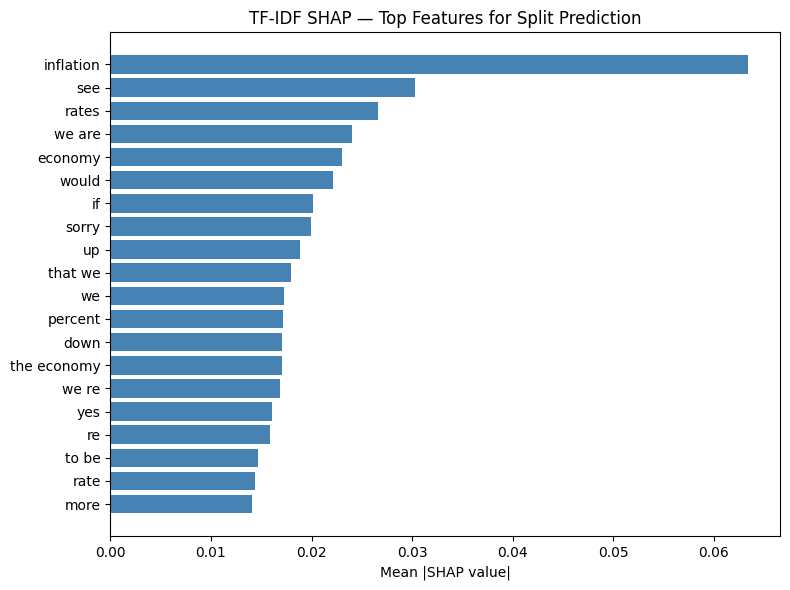

In [13]:
from sklearn.pipeline import Pipeline

train_texts = turns_wide.loc[tr,"text"].tolist()
test_texts  = turns_wide.loc[te,"text"].tolist()
y_split_tr  = turns_wide.loc[tr,"split"].values.astype(int)
y_split_te  = turns_wide.loc[te,"split"].values.astype(int)

tfidf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                              sublinear_tf=True, min_df=3)),
    ("clf",   LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
])
tfidf_pipe.fit(train_texts, y_split_tr)
tfidf_pred = tfidf_pipe.predict_proba(test_texts)[:,1]
tfidf_auc  = roc_auc_score(y_split_te, tfidf_pred)
print(f"TF-IDF AUC (predict split): {tfidf_auc:.3f}")

# SHAP on test set (subset for speed)
explainer   = shap.LinearExplainer(tfidf_pipe["clf"],
                                    tfidf_pipe["tfidf"].transform(train_texts))
Xte_tfidf   = tfidf_pipe["tfidf"].transform(test_texts[:500])
shap_values = explainer.shap_values(Xte_tfidf)
if isinstance(shap_values, list): shap_vals = shap_values[1]
else: shap_vals = shap_values

feat_names = tfidf_pipe["tfidf"].get_feature_names_out()
mean_shap  = np.abs(shap_vals).mean(axis=0)
top_idx    = np.argsort(mean_shap)[::-1][:30]
print("\nTop 30 TF-IDF features by mean |SHAP|:")
for i in top_idx[:30]:
    print(f"  {feat_names[i]:25s}  {mean_shap[i]:.4f}")

# SHAP bar plot
fig, ax = plt.subplots(figsize=(8,6))
ax.barh([feat_names[i] for i in top_idx[:20]][::-1],
        [mean_shap[i] for i in top_idx[:20]][::-1], color="steelblue")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("TF-IDF SHAP — Top Features for Split Prediction")
plt.tight_layout()
plt.savefig("tfidf_shap_disagreement.png", dpi=150); plt.show()

## 4. Multi-Head DeBERTa (Binary)

```
turn text → DeBERTa-v3-base → [CLS] 768-dim
                                    |
              one Linear(768, 2) head per LLM
              binary: 0=neutral  1=stanced
```

The shared encoder learns a stance-saturated text representation.
Each head is that LLM's decision rule over the shared space.

**Key design choices vs. 5-class version:**
- `num_labels=2` — binary cross-entropy is cleaner and calibration is easier
- Post-hoc threshold calibration: threshold t_k chosen per head on val set so predicted stanced rate ≈ observed stanced rate
- Swap uses calibrated thresholds — meaningful binary decomposition

In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class MultiHeadBinaryDataset(Dataset):
    def __init__(self, df, model_keys, max_length=512):
        self.df         = df.reset_index(drop=True)
        self.model_keys = model_keys
        self.max_length = max_length

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = tokenizer(
            str(row["text"]),
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "turn_uid":       row["turn_uid"],
            "is_split":       int(row["split"]),
        }
        for key in self.model_keys:
            item[f"label_{key}"] = int(row[f"binary_{key}"])   # 0 or 1
        return item

BATCH = 8
train_df = turns_wide[turns_wide["split_set"]=="train"]
val_df   = turns_wide[turns_wide["split_set"]=="val"]
test_df  = turns_wide[turns_wide["split_set"]=="test"]

train_loader = DataLoader(MultiHeadBinaryDataset(train_df, loaded), batch_size=BATCH,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(MultiHeadBinaryDataset(val_df,   loaded), batch_size=BATCH,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(MultiHeadBinaryDataset(test_df,  loaded), batch_size=BATCH,
                          shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Train: 2804  Val: 615  Test: 553


In [15]:
class MultiHeadBinaryModel(nn.Module):
    """Shared DeBERTa encoder + one binary Linear(768→2) head per LLM."""
    def __init__(self, encoder_name, model_keys):
        super().__init__()
        self.encoder = DebertaV2Model.from_pretrained(encoder_name)
        self.heads   = nn.ModuleDict({
            key: nn.Linear(768, 2) for key in model_keys
        })

    def forward(self, input_ids, attention_mask):
        enc = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = enc.last_hidden_state[:, 0, :].float()
        logits = {key: head(cls) for key, head in self.heads.items()}
        return logits, cls

model = MultiHeadBinaryModel(MODEL_NAME, loaded).to(device)
print(f"Encoder params: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"Heads: {list(model.heads.keys())} — Linear(768, 2) each")

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder params: 183,831,552
Heads: ['deepseekv3', 'gemini25flash', 'gpt-4o', 'llama33', 'mistrallarge_or', 'qwen25_72b'] — Linear(768, 2) each


## Training

- Epoch 1: encoder frozen, heads only (lr=1e-3)
- Epochs 2–3: full fine-tune, encoder at lr=2e-5
- Gradient accumulation 4 steps → effective batch 32
- Loss: sum of 6 binary cross-entropy losses (one per head)

In [16]:
# Resume from checkpoint (set SKIP_TRAINING=True to load saved weights)
SKIP_TRAINING   = True
CKPT_FROM_DRIVE = True
CKPT_PATH       = "/drive/MyDrive/central_bank_spillovers/multihead_turns_binary/best_model.pt"

if SKIP_TRAINING:
    if CKPT_FROM_DRIVE:
        from google.colab import drive as _drv
        _drv.mount("/drive", force_remount=False)
    assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
    model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
    model.eval()
    print(f"Loaded checkpoint: {CKPT_PATH}")
else:
    print("Training from scratch (SKIP_TRAINING=False)")

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Mounted at /drive
Loaded checkpoint: /drive/MyDrive/central_bank_spillovers/multihead_turns_binary/best_model.pt


In [17]:
if not SKIP_TRAINING:
    EPOCHS   = 3
    GRAD_ACC = 4
    model    = model.float()
    crit     = nn.CrossEntropyLoss()

    def make_opt(m, enc_lr=2e-5, head_lr=1e-3):
        return torch.optim.AdamW([
            {"params": m.encoder.parameters(), "lr": enc_lr,  "weight_decay": 0.01},
            {"params": m.heads.parameters(),   "lr": head_lr, "weight_decay": 0.01},
        ])

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        preds = {k:[] for k in loaded}; trues = {k:[] for k in loaded}; tot = 0.0
        for b in loader:
            ids  = b["input_ids"].to(device)
            mask = b["attention_mask"].to(device)
            lg, _ = model(ids, mask)
            loss  = sum(crit(lg[k], b[f"label_{k}"].to(device)) for k in loaded)
            tot  += loss.item()
            for k in loaded:
                preds[k].extend(lg[k].argmax(-1).cpu().tolist())
                trues[k].extend(b[f"label_{k}"].tolist())
        accs = {k: accuracy_score(trues[k], preds[k]) for k in loaded}
        return tot/len(loader), accs

    best_val_loss = float("inf")
    for epoch in range(1, EPOCHS+1):
        for p in model.encoder.parameters(): p.requires_grad = (epoch > 1)
        opt = make_opt(model, enc_lr=(2e-5 if epoch>1 else 0))
        print(f"Epoch {epoch}: {'frozen encoder' if epoch==1 else 'full fine-tune'}")
        model.train(); opt.zero_grad(); run_loss = 0.0
        for step, b in enumerate(train_loader, 1):
            ids  = b["input_ids"].to(device)
            mask = b["attention_mask"].to(device)
            lg, _ = model(ids, mask)
            loss  = sum(crit(lg[k], b[f"label_{k}"].to(device)) for k in loaded) / GRAD_ACC
            loss.backward(); run_loss += loss.item() * GRAD_ACC
            if step % GRAD_ACC == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); opt.zero_grad()
            if step % 100 == 0:
                print(f"  step {step}/{len(train_loader)}  loss={run_loss/step:.4f}")
        val_loss, val_accs = evaluate(val_loader)
        print(f"  val_loss={val_loss:.4f}  mean_acc={np.mean(list(val_accs.values())):.3f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model_binary.pt")
            print(f"  → saved best checkpoint")
    model.load_state_dict(torch.load("best_model_binary.pt", map_location=device))
    print("Training complete.")

In [18]:
if not SKIP_TRAINING:
    from google.colab import drive as _drv
    _drv.mount("/drive", force_remount=False)
    SAVE_DIR = "/drive/MyDrive/central_bank_spillovers/multihead_turns_binary"
    os.makedirs(SAVE_DIR, exist_ok=True)
    torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pt")
    print(f"Saved to {SAVE_DIR}/best_model.pt")

## 5. Evaluation — Per-Head Binary Metrics

Report per-head: AUC, accuracy, F1 (stanced class), and observed vs. raw predicted stanced rate.
The stanced-rate gap motivates the calibration step in Section 6.

In [19]:
model.eval()
all_preds  = {k:[] for k in loaded}
all_probs  = {k:[] for k in loaded}   # P(stanced) from softmax
all_true   = {k:[] for k in loaded}

with torch.no_grad():
    for b in test_loader:
        ids  = b["input_ids"].to(device)
        mask = b["attention_mask"].to(device)
        lg, _ = model(ids, mask)
        for k in loaded:
            probs_k = torch.softmax(lg[k], dim=-1)[:,1].cpu().tolist()  # P(stanced)
            all_probs[k].extend(probs_k)
            all_preds[k].extend(lg[k].argmax(-1).cpu().tolist())
            all_true[k].extend(b[f"label_{k}"].tolist())

rows = []
for k in loaded:
    yp  = np.array(all_preds[k])
    yt  = np.array(all_true[k])
    ypr = np.array(all_probs[k])
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, pos_label=1, zero_division=0)
    auc = roc_auc_score(yt, ypr)
    obs_stanced  = yt.mean()
    pred_stanced = yp.mean()
    rows.append({"Model":MODELS[k], "AUC":f"{auc:.3f}", "Accuracy":f"{acc:.3f}",
                 "F1(stanced)":f"{f1:.3f}",
                 "Obs.stanced":f"{obs_stanced:.1%}",
                 "Raw pred.stanced":f"{pred_stanced:.1%}",
                 "Gap":f"{pred_stanced-obs_stanced:+.1%}"})
    print(f"{MODELS[k]:20s}  AUC={auc:.3f}  acc={acc:.3f}  F1={f1:.3f}  "
          f"obs={obs_stanced:.1%}  raw_pred={pred_stanced:.1%}  gap={pred_stanced-obs_stanced:+.1%}")

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("per_head_metrics_binary.csv", index=False)
display(metrics_df)

DeepSeek V3           AUC=0.608  acc=0.863  F1=0.000  obs=13.7%  raw_pred=0.0%  gap=-13.7%
Gemini 2.5 Flash      AUC=0.604  acc=0.736  F1=0.000  obs=26.4%  raw_pred=0.0%  gap=-26.4%
GPT-4o Mini           AUC=0.651  acc=0.761  F1=0.000  obs=23.9%  raw_pred=0.0%  gap=-23.9%
Llama 3.3             AUC=0.622  acc=0.725  F1=0.000  obs=27.5%  raw_pred=0.0%  gap=-27.5%
Mistral Large         AUC=0.620  acc=0.752  F1=0.000  obs=24.8%  raw_pred=0.0%  gap=-24.8%
Qwen 2.5 72B          AUC=0.587  acc=0.861  F1=0.000  obs=13.9%  raw_pred=0.0%  gap=-13.9%


,Model,AUC,Accuracy,F1(stanced),Obs.stanced,Raw pred.stanced,Gap
0,DeepSeek V3,0.608,0.863,0.000,13.7%,0.0%,-13.7%
1,Gemini 2.5 Flash,0.604,0.736,0.000,26.4%,0.0%,-26.4%
2,GPT-4o Mini,0.651,0.761,0.000,23.9%,0.0%,-23.9%
3,Llama 3.3,0.622,0.725,0.000,27.5%,0.0%,-27.5%
4,Mistral Large,0.620,0.752,0.000,24.8%,0.0%,-24.8%
5,Qwen 2.5 72B,0.587,0.861,0.000,13.9%,0.0%,-13.9%


## 6. Threshold Calibration per Head

**Why**: some heads over-predict stanced (negative gap) or under-predict (positive gap).
For the swap analysis to be meaningful, each head must cross the neutral/stanced boundary
at a rate that matches its LLM's observed behavior.

**Method**: for each head, find threshold `t_k` on the **val set** such that
`mean(P(stanced) > t_k)` ≈ observed stanced rate for that LLM.
Default argmax corresponds to `t_k = 0.5`; calibrated threshold shifts this.

This is threshold calibration, not temperature scaling. It directly controls which turns
each head calls stanced without changing the learned representation.

In [20]:
# Collect P(stanced) on val set for each head
model.eval()
val_probs = {k:[] for k in loaded}
val_true  = {k:[] for k in loaded}

with torch.no_grad():
    for b in val_loader:
        ids  = b["input_ids"].to(device)
        mask = b["attention_mask"].to(device)
        lg, _ = model(ids, mask)
        for k in loaded:
            val_probs[k].extend(torch.softmax(lg[k],-1)[:,1].cpu().tolist())
            val_true[k].extend(b[f"label_{k}"].tolist())

# Observed stanced rate per model (on full corpus, not just val)
obs_rate = {k: turns_wide[f"binary_{k}"].mean() for k in loaded}

# Find threshold per head: bisect over [0,1] to match observed rate
from scipy.optimize import brentq

thresholds = {}
calib_rows = []
for k in loaded:
    probs  = np.array(val_probs[k])
    target = obs_rate[k]
    # f(t) = predicted_rate(t) - target; find root
    try:
        t_k = brentq(lambda t: (probs > t).mean() - target, 0.001, 0.999)
    except ValueError:
        # Falls back to closest achievable threshold
        t_k = 0.5
        print(f"Warning: could not calibrate {k}, using 0.5")
    thresholds[k] = t_k
    cal_rate = (probs > t_k).mean()
    calib_rows.append({"Model":MODELS[k],
                       "Observed stanced rate":f"{target:.1%}",
                       "Default (t=0.5) rate":f"{(probs>0.5).mean():.1%}",
                       "Calibrated threshold":f"{t_k:.3f}",
                       "Calibrated rate":f"{cal_rate:.1%}",
                       "Residual gap":f"{cal_rate-target:+.1%}"})
    print(f"{MODELS[k]:20s}  obs={target:.1%}  t={t_k:.3f}  cal_rate={cal_rate:.1%}")

calib_df = pd.DataFrame(calib_rows)
calib_df.to_csv("calibration_thresholds.csv", index=False)
display(calib_df)

DeepSeek V3           obs=15.3%  t=0.096  cal_rate=15.3%
Gemini 2.5 Flash      obs=29.4%  t=0.200  cal_rate=29.4%
GPT-4o Mini           obs=26.1%  t=0.314  cal_rate=26.2%
Llama 3.3             obs=30.2%  t=0.347  cal_rate=30.1%
Mistral Large         obs=26.6%  t=0.308  cal_rate=26.7%
Qwen 2.5 72B          obs=16.1%  t=0.161  cal_rate=16.1%


,Model,Observed stanced rate,Default (t=0.5) rate,Calibrated threshold,Calibrated rate,Residual gap
0,DeepSeek V3,15.3%,0.0%,0.096,15.3%,-0.0%
1,Gemini 2.5 Flash,29.4%,0.0%,0.200,29.4%,+0.1%
2,GPT-4o Mini,26.1%,0.0%,0.314,26.2%,+0.1%
3,Llama 3.3,30.2%,0.0%,0.347,30.1%,-0.1%
4,Mistral Large,26.6%,0.0%,0.308,26.7%,+0.1%
5,Qwen 2.5 72B,16.1%,0.0%,0.161,16.1%,+0.0%


In [21]:
# Faithfulness check: apply calibrated thresholds to test set
faith_rows = []
for k in loaded:
    ypr  = np.array(all_probs[k])
    yt   = np.array(all_true[k])
    t_k  = thresholds[k]
    yp_cal = (ypr > t_k).astype(int)
    f1_cal = f1_score(yt, yp_cal, pos_label=1, zero_division=0)
    auc_k  = roc_auc_score(yt, ypr)
    faith_rows.append({"Model":MODELS[k],
                       "AUC":f"{auc_k:.3f}",
                       "F1 (calibrated)":f"{f1_cal:.3f}",
                       "Calibrated stanced rate":f"{yp_cal.mean():.1%}",
                       "Observed stanced rate":f"{yt.mean():.1%}"})

faith_df = pd.DataFrame(faith_rows)
faith_df.to_csv("faithfulness_check.csv", index=False)
display(faith_df)
print("\nAUC is unaffected by threshold calibration (rank-based metric).")
print("F1 may improve or worsen depending on whether default 0.5 was already optimal.")

,Model,AUC,F1 (calibrated),Calibrated stanced rate,Observed stanced rate
0,DeepSeek V3,0.608,0.180,16.5%,13.7%
1,Gemini 2.5 Flash,0.604,0.376,35.1%,26.4%
2,GPT-4o Mini,0.651,0.376,32.9%,23.9%
3,Llama 3.3,0.622,0.366,34.7%,27.5%
4,Mistral Large,0.620,0.353,34.7%,24.8%
5,Qwen 2.5 72B,0.587,0.160,20.1%,13.9%



AUC is unaffected by threshold calibration (rank-based metric).
F1 may improve or worsen depending on whether default 0.5 was already optimal.


## 7. Linear Probe — Frozen vs. Fine-Tuned CLS

Does fine-tuning improve the encoder's representation for disagreement prediction?
Train logistic regression on CLS vectors; target = `split` (binary disagreement event).
Compare frozen DeBERTa vs. fine-tuned shared encoder.

In [25]:
@torch.no_grad()
def extract_cls(encoder, df, max_length=512, batch_size=16):
    encoder.eval()
    all_cls = []
    loader  = DataLoader(MultiHeadBinaryDataset(df, loaded, max_length),
                         batch_size=batch_size, shuffle=False)
    for b in loader:
        ids  = b["input_ids"].to(device)
        mask = b["attention_mask"].to(device)
        out  = encoder(input_ids=ids, attention_mask=mask)
        all_cls.append(out.last_hidden_state[:,0,:].float().cpu().numpy())
    return np.vstack(all_cls)

print("Extracting fine-tuned CLS vectors...")
X_ft = extract_cls(model.encoder, turns_wide)

print("Loading frozen encoder...")
from transformers import DebertaV2Model as _DV2
frozen_enc = _DV2.from_pretrained(MODEL_NAME).to(device)
frozen_enc.eval()
print("Extracting frozen CLS vectors...")
X_base = extract_cls(frozen_enc, turns_wide)
del frozen_enc
import gc; gc.collect(); torch.cuda.empty_cache()
print("Done.")

Extracting fine-tuned CLS vectors...
Loading frozen encoder...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting frozen CLS vectors...
Done.


In [26]:
tr_m = (turns_wide["split_set"]=="train").values
te_m = (turns_wide["split_set"]=="test").values
y_split = turns_wide["split"].values.astype(int)

def probe_auc(X, label=""):
    sc  = StandardScaler()
    Xtr = sc.fit_transform(X[tr_m])
    Xte = sc.transform(X[te_m])
    clf = LogisticRegression(C=0.1, max_iter=500, random_state=SEED)
    clf.fit(Xtr, y_split[tr_m])
    prob = clf.predict_proba(Xte)[:,1]
    auc  = roc_auc_score(y_split[te_m], prob)
    print(f"  {label:30s}  AUC={auc:.3f}")
    return auc, prob

print("Predicting split from CLS embeddings:")
auc_base, _ = probe_auc(X_base, "Frozen DeBERTa CLS")
auc_ft,   prob_ft = probe_auc(X_ft,   "Fine-tuned CLS")
print(f"\nFine-tune lift: +{auc_ft-auc_base:.3f} AUC")

# Store for meeting-level handoff
turns_wide["disagree_risk"] = np.nan
turns_wide.loc[te_m, "disagree_risk"] = prob_ft

Predicting split from CLS embeddings:
  Frozen DeBERTa CLS              AUC=0.689
  Fine-tuned CLS                  AUC=0.689

Fine-tune lift: +0.000 AUC


In [27]:
# Continuous disagreement targets
print("Spearman rank correlations — fine-tuned CLS predictions vs. actual disagreement:")
sc   = StandardScaler()
Xtr  = sc.fit_transform(X_ft[tr_m])
Xte  = sc.transform(X_ft[te_m])

for target_name, target_vals in [
    ("split (binary)",      y_split),
    ("score_std_3way",      turns_wide["score_std_3way"].values),
    ("label_entropy",       turns_wide["label_entropy"].values),
    ("max_ordinal_gap",     turns_wide["max_ordinal_gap"].values),
]:
    reg  = Ridge(alpha=1.0).fit(Xtr, target_vals[tr_m])
    pred = reg.predict(Xte)
    rho  = spearmanr(target_vals[te_m], pred).correlation
    print(f"  {target_name:25s}  Spearman={rho:.3f}")

Spearman rank correlations — fine-tuned CLS predictions vs. actual disagreement:
  split (binary)             Spearman=0.211
  score_std_3way             Spearman=0.242
  label_entropy              Spearman=0.347
  max_ordinal_gap            Spearman=0.324


## 8. Swap Analysis — Encoding vs. Decision-Rule Disagreement (Binary)

Run the encoder **once** per split turn; apply all 6 calibrated binary heads to the **identical** CLS vector.

- If heads agree (all stanced or all neutral): disagreement was **encoding-level** — the text
  representation itself disambiguated the turn when processed by a neutral encoder
- If heads still disagree: **genuine decision-rule difference** — different learned
  neutral/stanced thresholds in the same feature space

Calibrated thresholds (Section 6) ensure each head crosses the neutral boundary at the
correct rate — the decomposition is not an artifact of miscalibration.

In [ ]:
test_split_df  = turns_wide[(turns_wide["split_set"]=="test") & (turns_wide["split"])].reset_index(drop=True)
split_loader   = DataLoader(MultiHeadBinaryDataset(test_split_df, loaded, max_length=512),
                            batch_size=4, shuffle=False)

model.eval()
swap_results = []
swap_probs   = {k:[] for k in loaded}

with torch.no_grad():
    for batch in split_loader:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        _, cls = model(ids, mask)
        for k in loaded:
            p_stanced = torch.softmax(model.heads[k](cls), -1)[:,1].cpu().tolist()
            swap_probs[k].extend(p_stanced)

# Apply calibrated thresholds
swap_preds = {k: (np.array(swap_probs[k]) > thresholds[k]).astype(int) for k in loaded}
n_swap     = len(test_split_df)

# Compute per-turn agreement
for i in range(n_swap):
    preds_i = [swap_preds[k][i] for k in loaded]
    n_unique = len(set(preds_i))
    n_stanced_i = sum(preds_i)
    swap_results.append({
        "turn_uid":  test_split_df.iloc[i]["turn_uid"],
        "n_unique":  n_unique,
        "n_stanced_heads": n_stanced_i,
        **{f"pred_{k}": swap_preds[k][i] for k in loaded},
    })

swap_df = pd.DataFrame(swap_results)

print(f"Swap Analysis — {n_swap} split turns (held-out test, shared encoder)\n")
unanimous  = (swap_df["n_unique"]==1).mean()
partial    = ((swap_df["n_unique"]>1) & (swap_df["n_unique"]<len(loaded))).mean()
all_differ = (swap_df["n_unique"]==len(loaded)).mean()

print(f"  All 6 heads agree (encoding-level):   {unanimous:.1%}  ({int(unanimous*n_swap)} turns)")
print(f"  Partial agreement:                     {partial:.1%}  ({int(partial*n_swap)} turns)")
print(f"  All 6 heads differ:                    {all_differ:.1%}  ({int(all_differ*n_swap)} turns)")
print(f"\n  Decision-rule disagreement survives: {1-unanimous:.1%}")
print(f"  ≈ encoding / decision-rule split: {unanimous:.0%} / {1-unanimous:.0%}")

print("\nPairwise disagreement rates under shared CLS (calibrated):")
pair_rows = []
for a, b in combinations(loaded, 2):
    d = (swap_df[f"pred_{a}"] != swap_df[f"pred_{b}"]).mean()
    pair_rows.append((MODELS[a], MODELS[b], d))
for a, b, d in sorted(pair_rows, key=lambda x: x[2]):
    print(f"  {a:20s} <-> {b:20s}: {d:.1%}")

swap_df.to_csv("swap_results_binary.csv", index=False)

In [ ]:
# Swap decomposition figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: stacked bar — unanimous vs. partial vs. all-differ
labels = ["Unanimous\n(encoding)", "Partial", "All differ\n(decision-rule)"]
vals   = [unanimous, partial, all_differ]
colors = ["#2196F3", "#FFC107", "#F44336"]
axes[0].bar(labels, vals, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_ylabel("Fraction of split turns")
axes[0].set_title("Swap Decomposition\n(calibrated binary heads, shared encoder)")
for i, v in enumerate(vals):
    axes[0].text(i, v+0.01, f"{v:.1%}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, max(vals)*1.2)

# Right: pairwise disagreement heatmap
pair_matrix = pd.DataFrame(index=[MODELS[k] for k in loaded],
                            columns=[MODELS[k] for k in loaded], dtype=float)
for k in loaded:
    pair_matrix.loc[MODELS[k], MODELS[k]] = 0.0
for a, b in combinations(loaded, 2):
    d = (swap_df[f"pred_{a}"] != swap_df[f"pred_{b}"]).mean()
    pair_matrix.loc[MODELS[a], MODELS[b]] = d
    pair_matrix.loc[MODELS[b], MODELS[a]] = d

sns.heatmap(pair_matrix.astype(float), ax=axes[1], annot=True, fmt=".2f",
            cmap="Blues", vmin=0, vmax=0.5,
            xticklabels=[m.split()[0] for m in pair_matrix.columns],
            yticklabels=[m.split()[0] for m in pair_matrix.index])
axes[1].set_title("Pairwise Disagreement Rate\n(shared CLS, calibrated thresholds)")

plt.tight_layout()
plt.savefig("swap_decomposition_binary.png", dpi=150); plt.show()

## 9. Gradient Attribution per Head

Gradient of the predicted-class logit w.r.t. input word embeddings (∂logit/∂embedding), L2-normed per token.
Run on split turns in the test set. Identifies which tokens each head attends to when deciding stanced vs. neutral.

Comparing attribution patterns across heads reveals whether heads use the same vocabulary with different thresholds (shared cues) or truly different vocabulary (perceptual difference).

In [ ]:
STOP_WORDS = {
    # original
    "the","and","of","to","in","is","that","for","it","we","on","at","a","an",
    "be","as","by","are","this","with","have","from","our","has","was",
    "will","been","or","which","but","not","##","[cls]","[sep]","[unk]",
    # add: Q&A conversational filler
    "you","know","think","question","well","now","there","would","what",
    "yes","see","really","more","very","one","also","so","do","just",
    "get","say","mean","said","going","want","way","actually","right",
}

token_scores = {k:{} for k in loaded}
model.eval()
split_loader2 = DataLoader(MultiHeadBinaryDataset(test_split_df, loaded, max_length=512),
                           batch_size=4, shuffle=False)

for batch in split_loader2:
    ids  = batch["input_ids"].to(device)
    mask = batch["attention_mask"].to(device)
    for k in loaded:
        emb = model.encoder.embeddings.word_embeddings(ids)
        emb.retain_grad()
        out = model.encoder(inputs_embeds=emb, attention_mask=mask)
        cls = out.last_hidden_state[:,0,:].float()
        lg  = model.heads[k](cls)
        # Gradient w.r.t. predicted class (stanced or neutral)
        lg[range(len(lg)), lg.argmax(-1)].sum().backward(retain_graph=True)
        if emb.grad is None:
            model.zero_grad(); continue
        imp = emb.grad.norm(dim=-1).detach().cpu().numpy()
        for b_idx in range(ids.shape[0]):
            toks = tokenizer.convert_ids_to_tokens(ids[b_idx].cpu().tolist())
            for tok, sc in zip(toks, imp[b_idx]):
                clean = tok.replace("\u2581","").replace("##","").lower()
                if clean and clean not in STOP_WORDS and len(clean) > 2:
                    token_scores[k][clean] = token_scores[k].get(clean,0) + sc
        model.zero_grad()

print(f"Attribution complete over {len(test_split_df)} split turns.")

In [ ]:
TOP_N = 20
ncol  = 3
nrow  = int(np.ceil(len(loaded)/ncol))
palette = sns.color_palette("tab10", len(loaded))
fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 4*nrow))
axes = np.array(axes).reshape(-1)

for i, k in enumerate(loaded):
    top = sorted(token_scores[k].items(), key=lambda x:x[1], reverse=True)[:TOP_N]
    if not top: continue
    words, scores = zip(*top)
    axes[i].barh(list(words)[::-1], list(scores)[::-1], color=palette[i])
    axes[i].set_title(MODELS[k])
    axes[i].set_xlabel("Cumulative gradient norm")

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Gradient Attribution per Head — Split Turns (stanced/neutral boundary)", y=1.01)
plt.tight_layout()
plt.savefig("gradient_attribution_binary.png", dpi=150, bbox_inches="tight"); plt.show()

# Shared cues: tokens in top-20 for all 6 heads
top20_sets = [set(t for t,_ in sorted(ts.items(),key=lambda x:x[1],reverse=True)[:20])
              for ts in token_scores.values()]
shared = set.intersection(*top20_sets)
print(f"\nTokens in top-20 attribution for ALL 6 heads: {sorted(shared)}")
print("(These are the cues all models attend to — shared signals, different thresholds)")

## 10. Meeting-Level Disagreement — Handoff to Spillover VAR

Aggregate to (bank, meeting) level. This cell is unchanged from the 5-class version —
it uses the original 6-model labels directly, not the head predictions.

The binary model contributes `disagree_risk` (logistic probe on fine-tuned CLS)
as a text-based prediction of disagreement for periods without direct LLM labels.

In [28]:
# Aggregate to meeting level
turns_wide["date"] = pd.to_datetime(turns_wide["date"].astype(str), errors="coerce")
turns_wide["meeting"] = turns_wide["date"].dt.to_period("M").astype(str)

agg = (turns_wide
       .groupby(["bank","meeting"])
       .agg(
           mean_stance=("mean_stance","mean"),
           disagreement=("score_std_3way","mean"),
           sign_conflict_rate=("sign_conflict","mean"),
           n_turns=("turn_uid","count"),
           disagree_risk=("disagree_risk","mean"),
       )
       .reset_index())

# Text-predicted disagreement (Ridge on fine-tuned CLS, test set only)
sc  = StandardScaler()
X_all_ft = X_ft   # already extracted above
Xtr_ft   = sc.fit_transform(X_all_ft[tr_m])
Xte_ft   = sc.transform(X_all_ft[te_m])
reg_std3 = Ridge(alpha=1.0).fit(Xtr_ft, turns_wide.loc[tr_m,"score_std_3way"].values)
turns_wide["pred_std3"] = reg_std3.predict(sc.transform(X_all_ft))

rho_turn = spearmanr(
    turns_wide.loc[te_m,"score_std_3way"],
    turns_wide.loc[te_m,"pred_std3"]
).correlation
print(f"Turn-level Spearman (pred vs actual score_std_3way, test): {rho_turn:.3f}")

# Model-choice spread: SD of 6 per-model meeting stance means
stance3_cols = [f"score3_{k}" for k in loaded]
meeting_stances = {}
for k in loaded:
    ms = (turns_wide.groupby(["bank","meeting"])[f"score3_{k}"].mean())
    meeting_stances[k] = ms

meeting_stance_df = pd.DataFrame(meeting_stances)
agg2 = agg.set_index(["bank","meeting"])
agg2["model_choice_spread"] = meeting_stance_df.std(axis=1, ddof=0)
agg2 = agg2.reset_index()

# Meeting-level Spearman
pred_meeting = turns_wide.groupby(["bank","meeting"])["pred_std3"].mean().reset_index()
agg3 = agg2.merge(pred_meeting, on=["bank","meeting"], how="left")

te_meetings = turns_wide.loc[te_m].groupby(["bank","meeting"])["turn_uid"].first().reset_index()[["bank","meeting"]]
te_mask = agg3.set_index(["bank","meeting"]).index.isin(te_meetings.set_index(["bank","meeting"]).index)

rho_meeting = spearmanr(
    agg3.loc[te_mask,"disagreement"],
    agg3.loc[te_mask,"pred_std3"]
).correlation
rho_spread = spearmanr(
    agg3.loc[te_mask,"disagreement"],
    agg3.loc[te_mask,"model_choice_spread"]
).correlation

print(f"Meeting-level Spearman (pred vs actual disagreement, test): {rho_meeting:.3f}  (n={te_mask.sum()} meetings)")
print(f"Meeting-level Spearman (disagreement vs model_choice_spread): {rho_spread:.3f}")
print("Note: disagreement and model_choice_spread share variance — treat as co-movement, not independent validation.")

Turn-level Spearman (pred vs actual score_std_3way, test): 0.242
Meeting-level Spearman (pred vs actual disagreement, test): 0.279  (n=27 meetings)
Meeting-level Spearman (disagreement vs model_choice_spread): 0.777
Note: disagreement and model_choice_spread share variance — treat as co-movement, not independent validation.


In [29]:
# Save meeting-level handoff CSV for the spillover VAR
agg3["is_test"] = te_mask  # remove .values — te_mask is already an ndarray
handoff_cols = ["bank","meeting","mean_stance","disagreement","pred_std3",
                "model_choice_spread","sign_conflict_rate","disagree_risk","n_turns","is_test"]
handoff = agg3[[c for c in handoff_cols if c in agg3.columns]].copy()
handoff.to_csv("meeting_disagreement_for_var.csv", index=False)
print(f"Saved meeting_disagreement_for_var.csv ({len(handoff)} rows)")
display(handoff.head())

Saved meeting_disagreement_for_var.csv (161 rows)


,bank,meeting,mean_stance,disagreement,pred_std3,model_choice_spread,sign_conflict_rate,disagree_risk,n_turns,is_test
0,BoE,NaT,0.007635,0.114783,0.117174,0.023396,0.020112,0.269889,895,True
1,ECB,2015-01,-0.205882,0.109611,0.133298,0.029412,0.058824,NaN,17,False
2,ECB,2015-03,-0.303030,0.232804,0.168806,0.124943,0.000000,NaN,11,False
3,ECB,2015-04,-0.044444,0.079146,0.145230,0.073703,0.066667,NaN,15,False
4,ECB,2015-06,-0.037879,0.050820,0.089451,0.040797,0.000000,NaN,22,False


## 11. Save & Download All Outputs

In [ ]:
import shutil

outputs = [
    "per_head_metrics_binary.csv",
    "calibration_thresholds.csv",
    "faithfulness_check.csv",
    "swap_results_binary.csv",
    "swap_decomposition_binary.png",
    "gradient_attribution_binary.png",
    "tfidf_shap_disagreement.png",
    "meeting_disagreement_for_var.csv",
]

try:
    from google.colab import drive as _drv
    _drv.mount("/drive", force_remount=False)
    SAVE_DIR = "/drive/MyDrive/central_bank_spillovers/multihead_turns_binary"
    os.makedirs(SAVE_DIR, exist_ok=True)
    for f in outputs:
        if os.path.exists(f):
            shutil.copy(f, f"{SAVE_DIR}/{f}")
            print(f"  saved: {f}")
    print(f"\nAll outputs saved to {SAVE_DIR}")
except Exception as e:
    print(f"Drive save skipped ({e}); files remain in /content/")

try:
    from google.colab import files as _f
    for f in outputs:
        if os.path.exists(f):
            _f.download(f)
except:
    pass

In [ ]:
# ── Embedding Space: Frozen vs Fine-Tuned CLS (UMAP), colored by swap category
# Requires: X_base, X_ft, turns_wide, swap_df, te_m, loaded
# Run after Section 8 (swap analysis)

!pip install -q umap-learn

import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── 1. Build category labels for test turns ───────────────────────────────────
test_df = turns_wide[te_m].copy().reset_index(drop=True)

swap_lookup = swap_df.set_index("turn_uid")["n_unique"].to_dict()

def get_category(row):
    uid = row["turn_uid"]
    if uid in swap_lookup:
        return "Encoding-level" if swap_lookup[uid] == 1 else "Decision-rule"
    elif row["n_stanced"] == 0:
        return "All neutral"
    elif row["n_stanced"] == len(loaded):
        return "All stanced"
    else:
        return "Other split"

test_df["category"] = test_df.apply(get_category, axis=1)
print(test_df["category"].value_counts().to_string())

# ── 2. UMAP ───────────────────────────────────────────────────────────────────
X_base_te = X_base[te_m]
X_ft_te   = X_ft[te_m]

print("Fitting UMAP on frozen CLS...")
coords_base = umap.UMAP(n_components=2, random_state=42,
                         n_neighbors=20, min_dist=0.1).fit_transform(X_base_te)

print("Fitting UMAP on fine-tuned CLS...")
coords_ft   = umap.UMAP(n_components=2, random_state=42,
                         n_neighbors=20, min_dist=0.1).fit_transform(X_ft_te)

print("Done.")

# ── 3. Plot ───────────────────────────────────────────────────────────────────
COLORS = {
    "All neutral":    "#90CAF9",
    "All stanced":    "#EF9A9A",
    "Encoding-level": "#FF9800",
    "Decision-rule":  "#B71C1C",
    "Other split":    "#BDBDBD",
}
SIZES = {
    "All neutral": 8, "All stanced": 12,
    "Encoding-level": 40, "Decision-rule": 60,
    "Other split": 15,
}
ALPHAS = {
    "All neutral": 0.4, "All stanced": 0.6,
    "Encoding-level": 0.85, "Decision-rule": 0.95,
    "Other split": 0.5,
}
ZORDER = {
    "All neutral": 1, "All stanced": 2,
    "Encoding-level": 3, "Decision-rule": 4,
    "Other split": 2,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_data = [
    (axes[0], coords_base, "Frozen DeBERTa CLS"),
    (axes[1], coords_ft,   "Fine-Tuned DeBERTa CLS"),
]

CAT_ORDER = ["All neutral", "All stanced", "Encoding-level", "Decision-rule"]

for ax, coords, title in plot_data:
    for cat in CAT_ORDER:
        mask = test_df["category"] == cat
        if mask.sum() == 0:
            continue
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=COLORS[cat],
            s=SIZES[cat],
            alpha=ALPHAS[cat],
            zorder=ZORDER[cat],
            label=f"{cat} (n={mask.sum()})",
            edgecolors="white" if SIZES[cat] > 15 else "none",
            linewidths=0.4,
        )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("UMAP 1", fontsize=10)
    ax.set_ylabel("UMAP 2", fontsize=10)
    ax.legend(fontsize=9, loc="best", framealpha=0.8)
    ax.set_xticks([]); ax.set_yticks([])   # UMAP axes are not interpretable

plt.suptitle(
    "CLS Embedding Space — Frozen vs Fine-Tuned DeBERTa\n"
    "(test set turns, colored by swap outcome)",
    fontsize=13
)
plt.tight_layout()
plt.savefig("embedding_space_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: embedding_space_umap.png")